# Phân tích dữ liệu khám phá (EDA)

## 1. Tổng quan

### 1.1 Thư viện 

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import collections
import joblib

### 1.2 Tổng quan về data

In [31]:
df = pd.read_csv(r"D:\maihoaa\SIC hè 2026\Project\Data\creditcard.csv\creditcard.csv")

In [32]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
print(f"Kích thước bảng : {df.shape}")

Kích thước bảng : (284807, 31)


In [34]:
# Kiểm tra giá trị bị  
missing_count = df.isnull().sum().sum()
print(f"Số ô bị thiếu: {missing_count}")

Số ô bị thiếu: 0


=> Dữ liệu không có ô nào bị thiếu

In [35]:
# Kiểm tra dòng trùng lặp
duplicate_count = df.duplicated().sum()
print(f"Số dòng bị trùng: {duplicate_count}")

Số dòng bị trùng: 1081


In [36]:
# Xóa các dòng trùng lặp
df = df.drop_duplicates()
df.shape

(283726, 31)

Xóa các dòng trùng lặp giúp tránh trường hợp mô hình bị học đi học lại một giao dịch quá nhiều lần, gây ra hiện tượng Overfitting

In [37]:
# Thông tin các cột
df.info()

<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-null  f

In [38]:
# Các chỉ số thống kê cơ bản từng cột
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


## 2. Đánh giá chênh lệch

### 2.1 Tổng quan về phân loại giao dịch (Class)

In [39]:
# Số lượng giao dịch
class_counts = df["Class"].value_counts()
# Tỉ lệ phần trăm
class_percentages = df["Class"].value_counts(normalize = True) * 100

print(f"Số lượng giao dịch bình thường (Class = 0) : {class_counts[0]:,} giao dịch")
print(f"Số lượng giao dịch bất thường (Class = 1) : {class_counts[1]:,} giao dịch")

print(f"Tỉ lệ giao dịch bình thường (Class = 0) : {class_percentages[0]:.4f}%")
print(f"Tỉ lệ giao dịch bất thường (Class = 1) : {class_percentages[1]:.4f}%")

Số lượng giao dịch bình thường (Class = 0) : 283,253 giao dịch
Số lượng giao dịch bất thường (Class = 1) : 473 giao dịch
Tỉ lệ giao dịch bình thường (Class = 0) : 99.8333%
Tỉ lệ giao dịch bất thường (Class = 1) : 0.1667%


### 2.2 Trực quan hóa mức độ chênh lệch

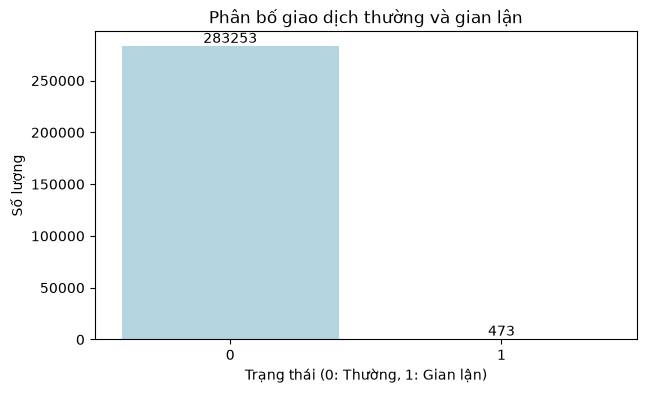

In [40]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data = df,
                   x="Class",
                   hue = "Class",
                   palette=["#ADD8E6","#D62728"],
                   legend=False)
plt.title("Phân bố giao dịch thường và gian lận")
plt.xlabel("Trạng thái (0: Thường, 1: Gian lận)")
plt.ylabel("Số lượng")

# Hiển thị số lượng cụ thể trên đầu mỗi cột
for i in ax.containers:
    ax.bar_label(i,)
    ax.set_xticks([0, 1])
ax.set_xticklabels(["0","1"])

plt.show()

Tập dữ liệu có 283,253 giao dịch thường (99.8333%) và chỉ có 473 giao dịch gian lận (0.1667%), do sự chênh lệch cao này, cần chuyển sang ưu tiên chỉ số Recall và F1-Score và áp dụng các kỹ thuật cân bằng dữ liệu

## 3. Phân tích Time và Amount

### 3.1 Độ lệch

In [41]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [42]:
skew_amount = df["Amount"].skew()
skew_time = df["Time"].skew()

print(f"Độ lệch của cột Amount : {skew_amount:.2f}")
print(f"Độ lệch của cột Time : {skew_time:.2f}")

Độ lệch của cột Amount : 16.98
Độ lệch của cột Time : -0.04


### 3.2 Phân bố

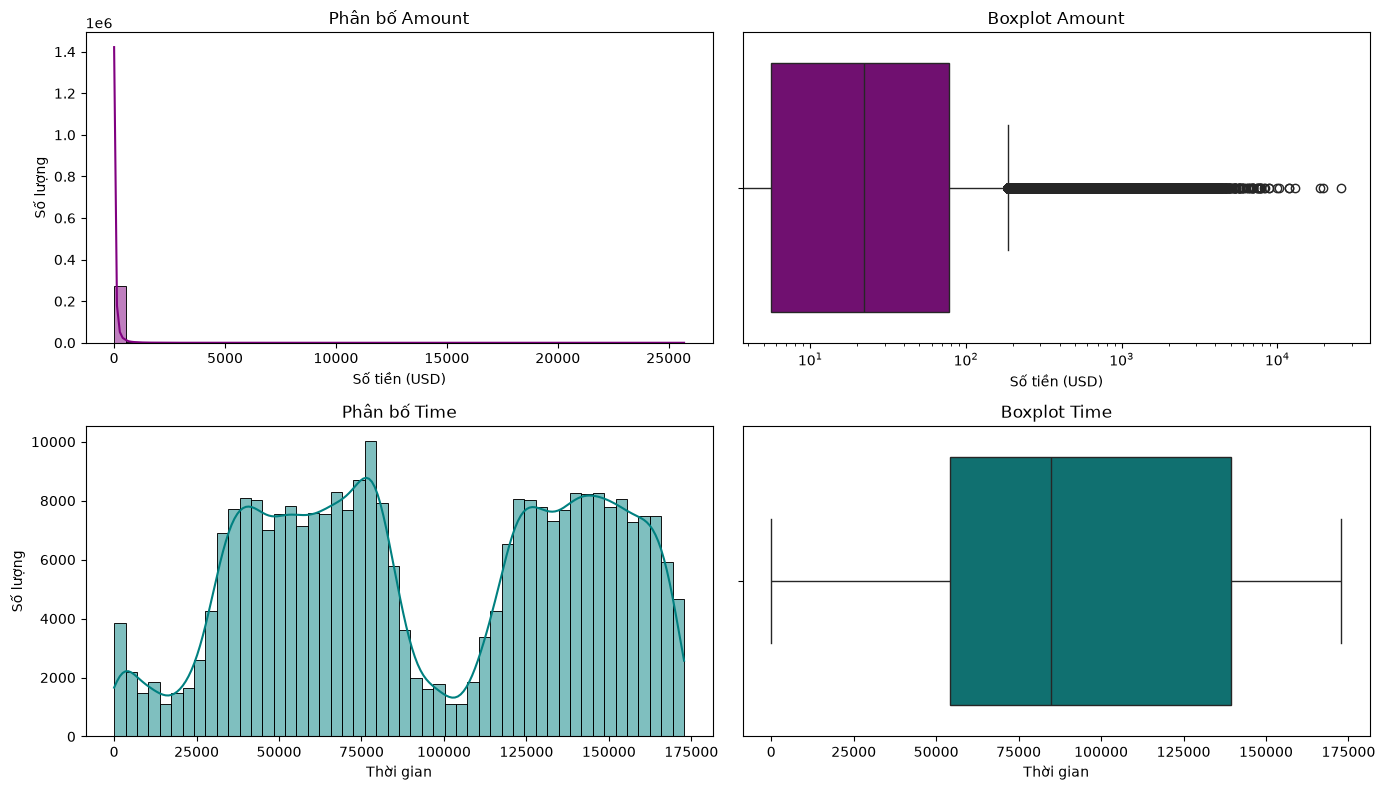

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Biểu đồ 1: Histogram Amount
sns.histplot(df["Amount"], bins=50, kde=True, ax=axes[0, 0], color="purple")
axes[0, 0].set_title("Phân bố Amount")
axes[0, 0].set_xlabel("Số tiền (USD)")
axes[0, 0].set_ylabel("Số lượng")

# Biểu đồ 2: Boxplot Amount
sns.boxplot(x=df["Amount"], ax=axes[0, 1], color="purple") 
axes[0, 1].set_title("Boxplot Amount")
axes[0, 1].set_xscale("log") # Dùng thang đo Logarithm
axes[0, 1].set_xlabel("Số tiền (USD)")

# Biểu đồ 3: Histogram Time
sns.histplot(df["Time"], bins=50, kde=True, ax=axes[1, 0], color="teal")
axes[1, 0].set_title("Phân bố Time")
axes[1, 0].set_xlabel("Thời gian")
axes[1, 0].set_ylabel("Số lượng")

# Biểu đồ 4: Boxplot Time
sns.boxplot(x=df["Time"], ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Boxplot Time")
axes[1, 1].set_xlabel("Thời gian")

plt.tight_layout()
plt.show()

Cột Amount:
    - Độ lệch Skewness rất cao (16.87), dữ liệu bị lệch phải nghiêm trọng
    - Phần lớn giao dịch tập trung trong khoảng 0-200 USD, xuất hiện rải rác các giao dịch lớn (> 1000 USD)
    - Nếu dùng StandardScaler, các giao dịch tiền tỷ sẽ làm méo toàn bộ quy mô của cột Amount
    => Sử dụng RobustScaler do trung vị (Median) và khoảng tứ phân vị (IQR). Không bị ảnh hưởng bởi giá trị ngoại lệ

Cột Time: 
    - Độ lệch Skewness gần bằng 0, dữ liệu phân bố trải đều trong 48 giờ
    - Phân bố 2 đỉnh phù hợp với thói quen sinh hoạt theo chu kỳ ngày/dêm của người dùng

## 4. So sánh đặc trưng giữa 2 lớp bình thường và gian lận

### 4.1 Biểu đồ tương quan của các biến giữa lớp bình thường (0) và gian lận (1)

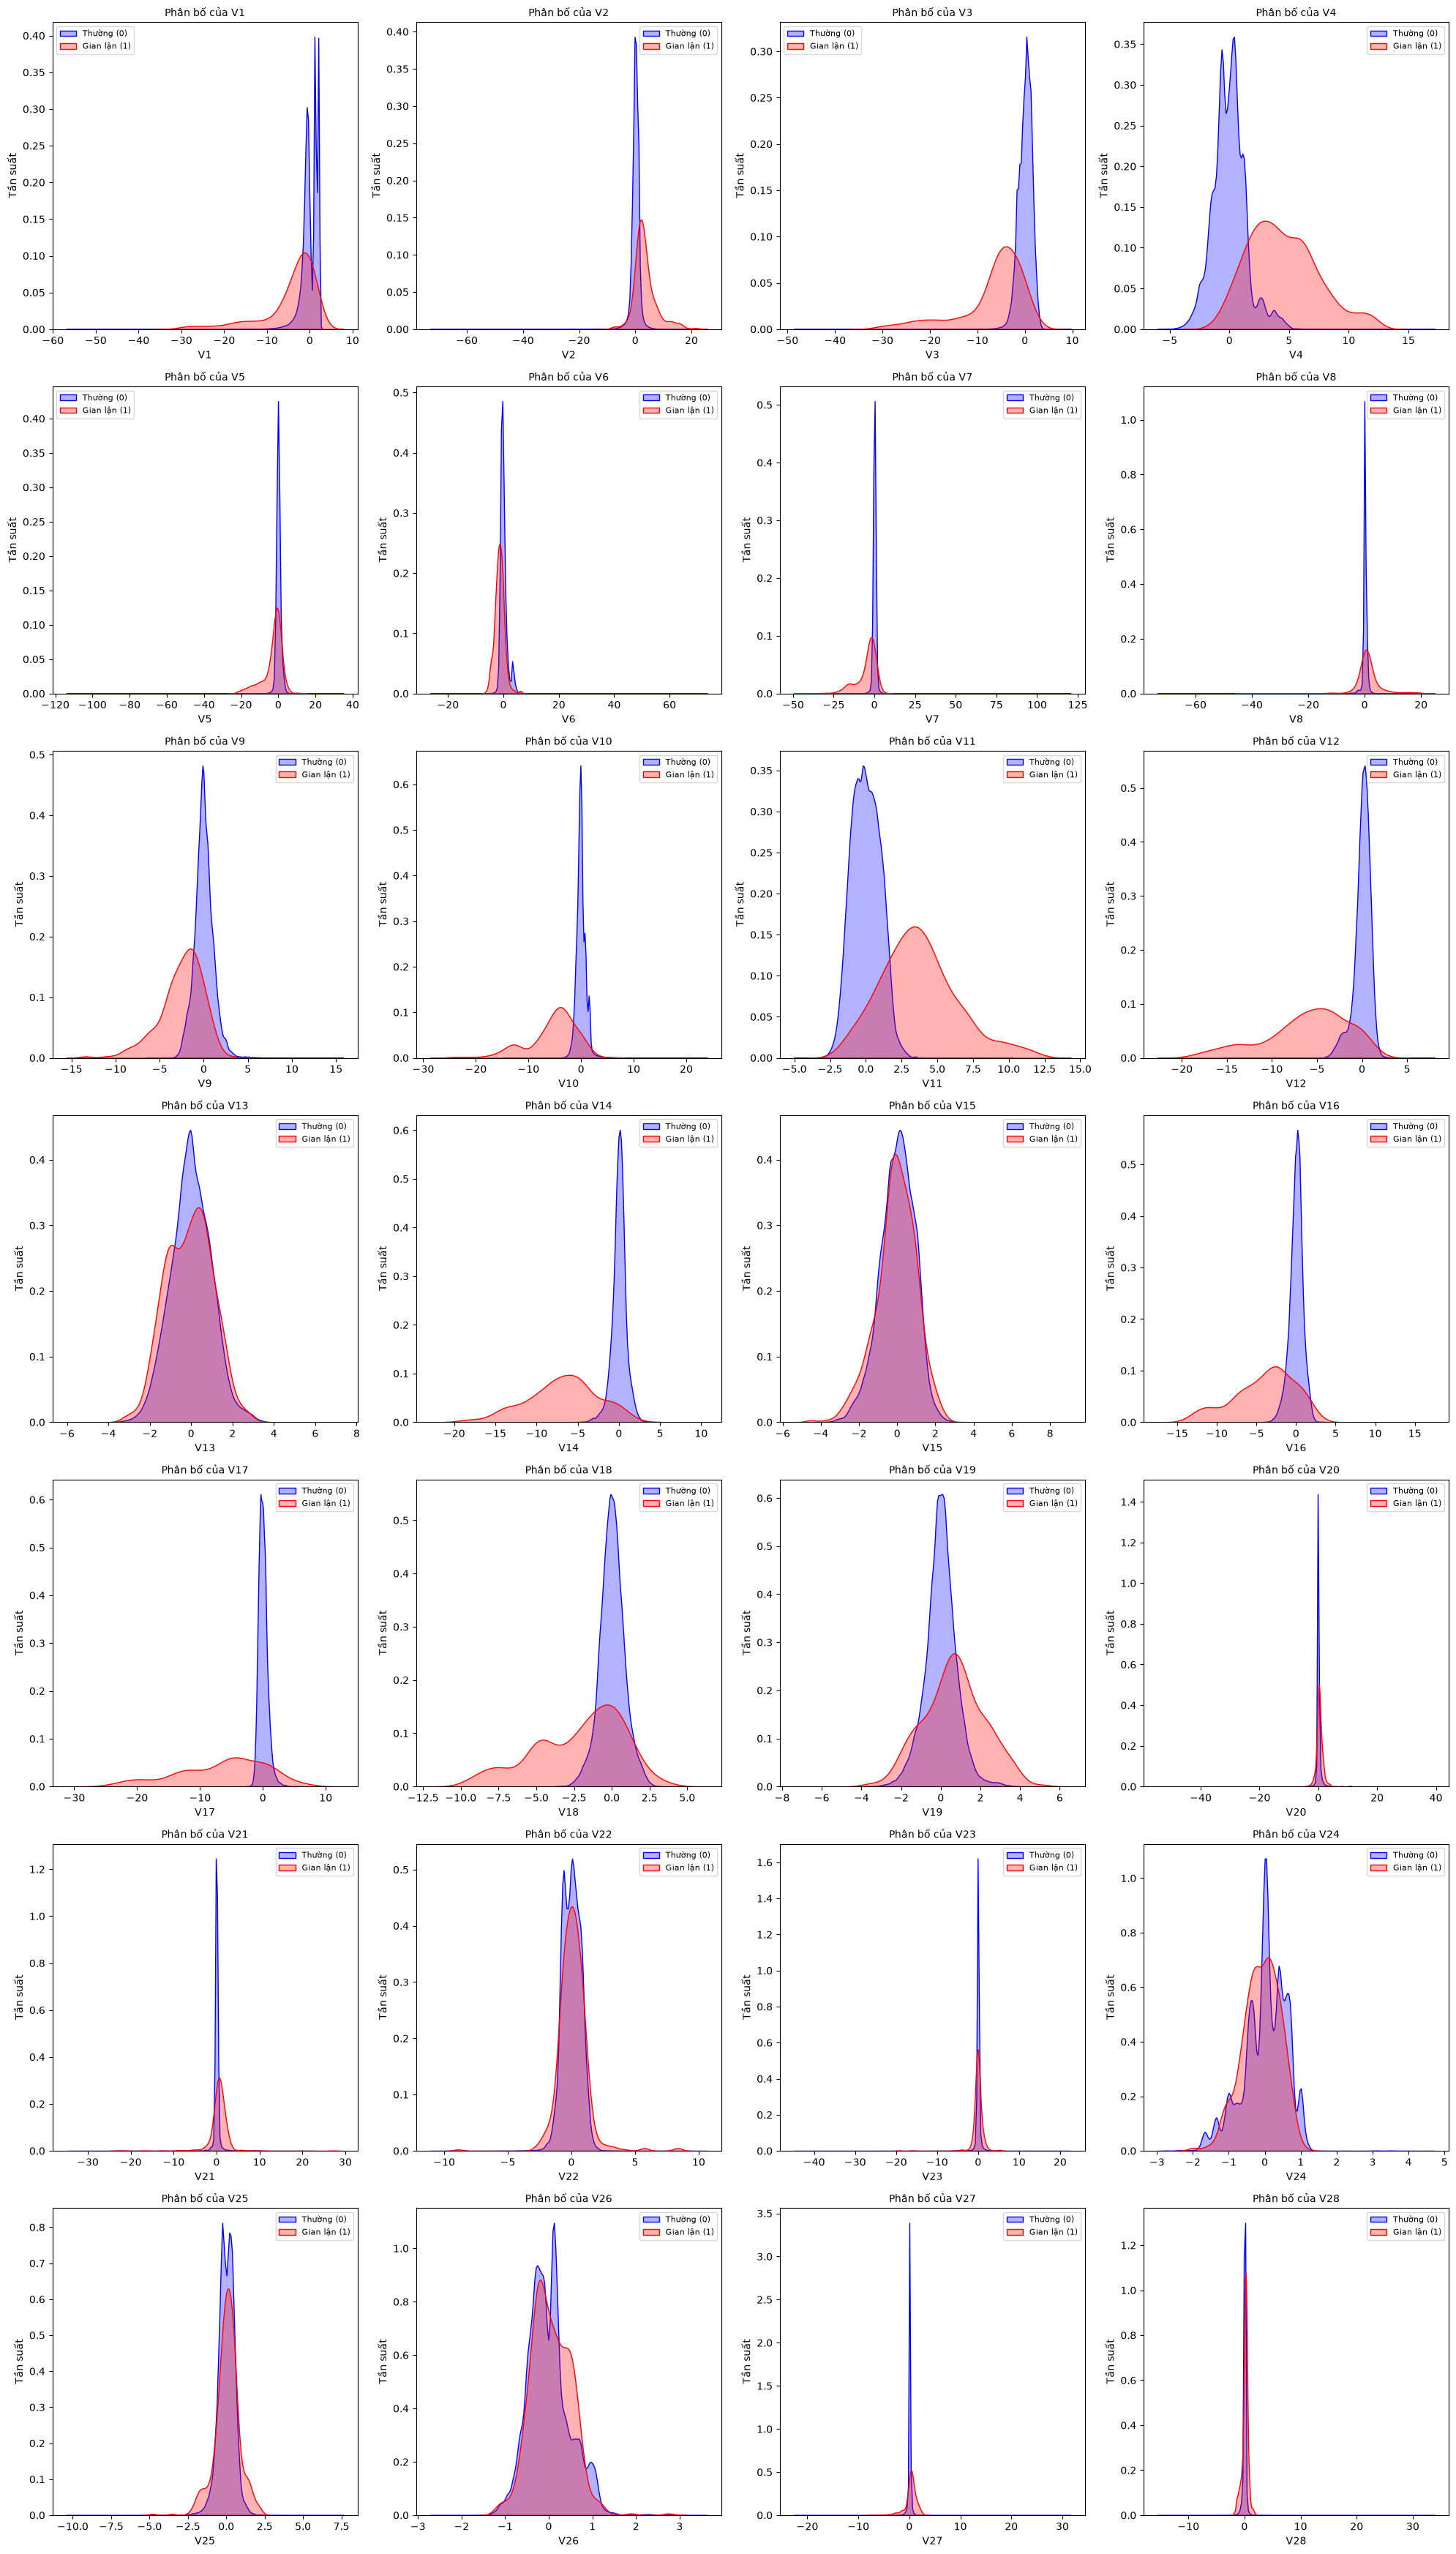

In [44]:
# Tạo danh sách tất cả 28 biến từ V1 đến V28
features_to_plot = [f"V{i}" for i in range(1, 29)]

plt.figure(figsize=(20, 35))

# Vẽ biểu đồ KDE cho 28 biến
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(7, 4, i)
    
    sns.kdeplot(df[df["Class"] == 0][col], label="Thường (0)", color="blue", fill=True, alpha=0.3)
    sns.kdeplot(df[df["Class"] == 1][col], label="Gian lận (1)", color="red", fill=True, alpha=0.3)
    
    plt.title(f"Phân bố của {col}", fontsize=10)
    plt.ylabel("Tần suất")
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.2 Hệ số tương quan của các biến giữa lớp bình thường (0) và gian lận (1)

In [45]:
# Tính hệ số tương quan
correlations = df.corr()["Class"].drop(["Class", "Amount", "Time"]) 
# Lấy giá trị trị tuyệt đối để đánh giá mức độ mạnh
abs_corr = correlations.abs().sort_values(ascending=False)

# - Mạnh: |r| >= 0.1
# - Vừa:  0.05 <= |r| < 0.1
# - Yếu:  |r| < 0.05

group_strong = abs_corr[abs_corr >= 0.1]
group_medium = abs_corr[(abs_corr >= 0.05) & (abs_corr < 0.1)]
group_weak = abs_corr[abs_corr < 0.05]

print("Nhóm tương quan mạnh:")
for col, val in group_strong.items():
    print(f"Cột {col} (|r| = {val:.4f})")

print("\nNhóm tương quan vừa:")
for col, val in group_medium.items():
    print(f"Cột {col} (|r| = {val:.4f})")

print("\nNhóm tương quan yếu:")
for col, val in group_weak.items():
    print(f"Cột {col:} (|r| = {val:.4f})")

Nhóm tương quan mạnh:
Cột V17 (|r| = 0.3135)
Cột V14 (|r| = 0.2934)
Cột V12 (|r| = 0.2507)
Cột V10 (|r| = 0.2070)
Cột V16 (|r| = 0.1872)
Cột V3 (|r| = 0.1823)
Cột V7 (|r| = 0.1723)
Cột V11 (|r| = 0.1491)
Cột V4 (|r| = 0.1293)
Cột V18 (|r| = 0.1053)

Nhóm tương quan vừa:
Cột V1 (|r| = 0.0945)
Cột V9 (|r| = 0.0940)
Cột V5 (|r| = 0.0878)
Cột V2 (|r| = 0.0846)

Nhóm tương quan yếu:
Cột V6 (|r| = 0.0439)
Cột V19 (|r| = 0.0336)
Cột V8 (|r| = 0.0331)
Cột V21 (|r| = 0.0264)
Cột V27 (|r| = 0.0219)
Cột V20 (|r| = 0.0215)
Cột V28 (|r| = 0.0097)
Cột V24 (|r| = 0.0072)
Cột V23 (|r| = 0.0063)
Cột V22 (|r| = 0.0049)
Cột V26 (|r| = 0.0043)
Cột V13 (|r| = 0.0039)
Cột V15 (|r| = 0.0033)
Cột V25 (|r| = 0.0032)


    - Các biến tương quan mạnh thể hiện sự tách biệt giữa 2 nhóm sẽ có vai trò quan trọng trong việc phân loại của các thuật toán học máy
    - Các biến tương quan yếu có thể được loại bỏ để giúp mô hình nhẹ hơn, giảm thời gian tính toán

## 5. Phân tích tương quan giữa các biến

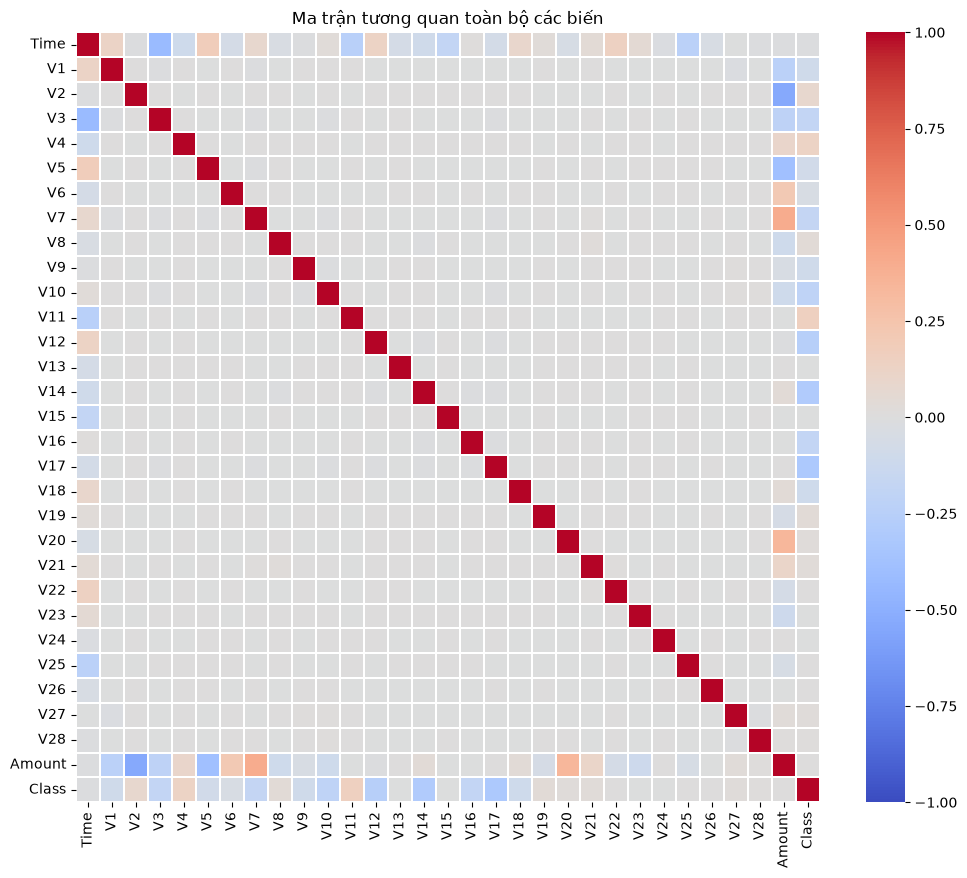

In [46]:
# Ma trận tương quan
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.1)
plt.title("Ma trận tương quan toàn bộ các biến")
plt.show()

Các biến từ V1 đến V28 hoàn toàn độc lập với nhau
=> Thuật toán XGBoost hoạt động hiệu quả 

# Tiền xử lý dữ liệu

# 1. Data Splitting

In [47]:
# Biến đổi Time thành chu kỳ giờ
df["Time"] = (df["Time"] / 3600) % 24

In [48]:
# Tách data thành X (Biến độc lập) và Y (Biến mục tiêu)
X = df.drop(columns = "Class")
y = df["Class"]

In [49]:
# Chia thành 2 tập Train và Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 2,
    stratify = y)

print(f"Kích thước X_train: {X_train.shape}")
print("\nPhân bố của 2 Class trong y_train:")
print(y_train.value_counts(normalize=True))
print(f"\nKích thước X_test: {X_test.shape}")
print("\nPhân bố của 2 Class trong trong y_test:")
print(y_test.value_counts(normalize=True))

Kích thước X_train: (226980, 30)

Phân bố của 2 Class trong y_train:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Kích thước X_test: (56746, 30)

Phân bố của 2 Class trong trong y_test:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


Sau khi tách, phân bố của 2 tập gần như giống nhau tuyệt đối

# 2. Chuẩn hóa

In [50]:
# Tạo bản sao tập dữ liệu
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

Sử dụng RobustScaler giúp đưa Amount và Time về cùng thang đo mới quanh trung vị (Median = 0), đồng bộ với dải giá trị của các biến V1 tới V28

In [51]:
# Khởi tạo RobustScaler cho Amount và Time
scaler_amount = RobustScaler()
scaler_hour = RobustScaler()

# fit và transform trên tập Train
X_train_scaled["Amount"] = scaler_amount.fit_transform(X_train[["Amount"]])
X_train_scaled["Time"] = scaler_hour.fit_transform(X_train[["Time"]])

#transform trên tập Test
X_test_scaled["Amount"] = scaler_amount.transform(X_test[["Amount"]])
X_test_scaled["Time"] = scaler_hour.transform(X_test[["Time"]])

In [52]:
# Xuất file Artifact (Cho Streaming Pipeline)
joblib.dump(scaler_amount, "scaler_amount.pkl")
joblib.dump(scaler_hour, "scaler_time.pkl")

['scaler_time.pkl']

In [53]:
X_train_scaled[["Amount", "Time"]].head()

,Amount,Time
29315,-0.114811,-0.593066
135141,-0.167340,0.861804
256808,-0.223074,0.554775
49924,1.486554,-0.311246
222822,-0.225303,0.085415


In [54]:
X_test_scaled[["Amount", "Time"]].head()

,Amount,Time
28153,1.951094,-0.610127
176448,-0.167201,-0.562669
189454,-0.097534,-0.383245
201725,0.515536,-0.204840
169662,0.487948,-0.657203


In [55]:
nan_train = X_train_scaled.isna().sum().sum()
nan_test = X_test_scaled.isna().sum().sum()
print(f"Số lượng giá trị NaN/Null trong X_train_scaled: {nan_train}")
print(f"Số lượng giá trị NaN/Null trong X_test_scaled: {nan_test}")

Số lượng giá trị NaN/Null trong X_train_scaled: 0
Số lượng giá trị NaN/Null trong X_test_scaled: 0


## 3. Xử lý mất cân bằng dữ liệu

Khắc phục tình trạng mất cân bằng dữ bằng cách sử dụng phương án Class Weighting trực tiếp trong mô hình thay cho SMOTE để tránh tạo dữ liệu giả lập, giảm rủi ro báo động giả 

## 4.Lưu trữ

In [56]:
np.savez_compressed(
    "credit_card_processed.npz",
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
)